# 📱 SMS Spam vs Ham Classification — Sentiment Analysis with RNN & LSTM
### Herald College Kathmandu | University of Wolverhampton
### Module: 6CS012 — Artificial Intelligence and Machine Learning
### Part III — Natural Language Processing Task

---
**Student:** *(Your Name)*  
**Student ID:** *(Your WLV ID)*  
**Dataset:** SMS Spam Collection v1  
**Total Messages:** 5,572 | **Classes:** 2 (spam / ham) | **Ham:** 4,825 | **Spam:** 747  

---


## 📦 Section 1: Install Dependencies and Import Libraries

In [ ]:
# Install required libraries (run once in Google Colab)
!pip install -q nltk wordcloud gensim
!pip install -q numpy==1.23.5 2>/dev/null || true


  Installing build dependencies ... done
  Getting requirements to build wheel ... error


In [ ]:
import os, re, string, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score, f1_score)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU:", gpus if gpus else "None (CPU mode)")
print("All libraries loaded ✅")


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries loaded ✅


---
## 📂 Section 2: Load the Dataset

Upload **spamvsham.csv** to Google Colab using the Files panel on the left,  
or mount Google Drive and set the correct path.


In [ ]:
# ── Option A: Upload directly ─────────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # select spamvsham.csv

# ── Option B: Mount Google Drive ──────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')

# ── Load CSV ──────────────────────────────────────────────────────────────
CSV_PATH = '/content/spamvsham.csv'   # adjust path if needed

df = pd.read_csv(CSV_PATH, encoding='latin-1', usecols=[0, 1])
df.columns = ['label', 'text']
df = df.dropna(subset=['label', 'text']).reset_index(drop=True)

print(f"Dataset shape  : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"\nLabel counts:")
print(df['label'].value_counts())
print(f"\nSample rows:")
df.head()

Dataset shape  : (5572, 2)
Columns        : ['label', 'text']

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Sample rows:


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# ── Encode labels: ham=0, spam=1 ──────────────────────────────────────────
df['label_enc'] = (df['label'] == 'spam').astype(int)

print("Label encoding: ham=0, spam=1")
print(df[['label','label_enc']].value_counts())

# ── Text length analysis ───────────────────────────────────────────────────
df['text_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

print(f"\nAverage message length (chars):")
print(df.groupby('label')['text_length'].mean().round(1))
print(f"\nAverage word count:")
print(df.groupby('label')['word_count'].mean().round(1))


Label encoding: ham=0, spam=1
label  label_enc
ham    0            4825
spam   1             747
Name: count, dtype: int64

Average message length (chars):
label
ham      71.0
spam    138.9
Name: text_length, dtype: float64

Average word count:
label
ham     14.2
spam    23.9
Name: word_count, dtype: float64


---
## 🔍 Section 3: Exploratory Data Analysis and Visualisation


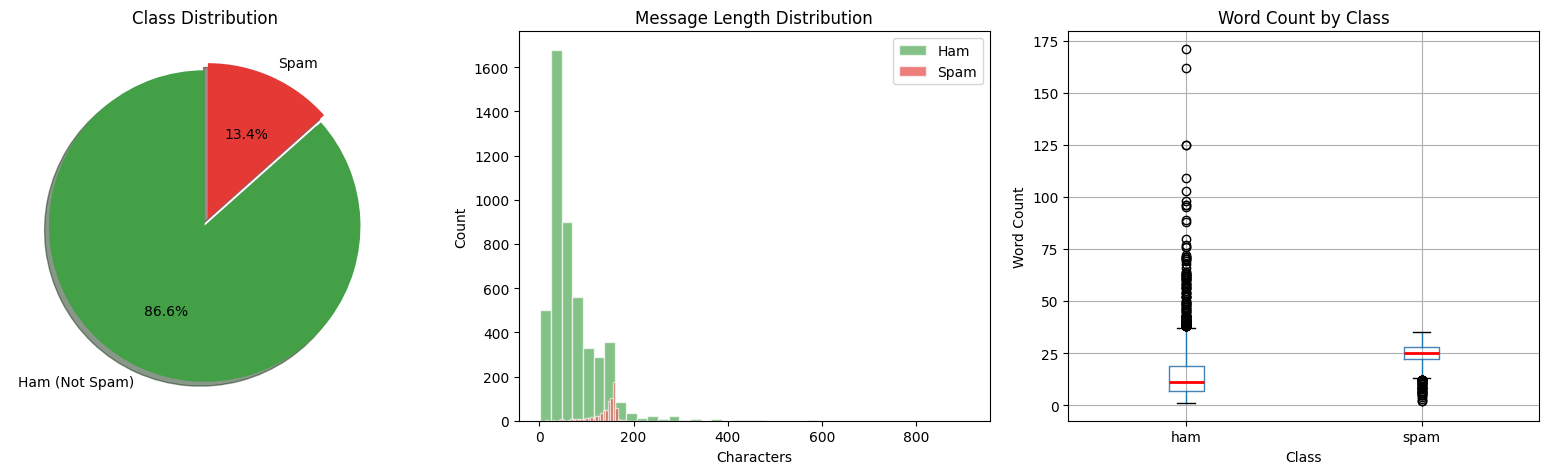

In [ ]:
# ── Class distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SMS Spam vs Ham — Exploratory Analysis', fontsize=14, fontweight='bold')

# Pie chart
counts = df['label'].value_counts()
axes[0].pie(counts, labels=['Ham (Not Spam)', 'Spam'], autopct='%1.1f%%',
            colors=['#43A047','#E53935'], startangle=90,
            explode=(0, 0.05), shadow=True)
axes[0].set_title('Class Distribution')

# Message length distribution
for label, color in [('ham','#43A047'), ('spam','#E53935')]:
    axes[1].hist(df[df['label']==label]['text_length'], bins=40,
                 alpha=0.65, color=color, label=label.capitalize(), edgecolor='white')
axes[1].set_title('Message Length Distribution')
axes[1].set_xlabel('Characters'); axes[1].set_ylabel('Count')
axes[1].legend()

# Word count box plot
df.boxplot(column='word_count', by='label', ax=axes[2],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Word Count by Class')
axes[2].set_xlabel('Class'); axes[2].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


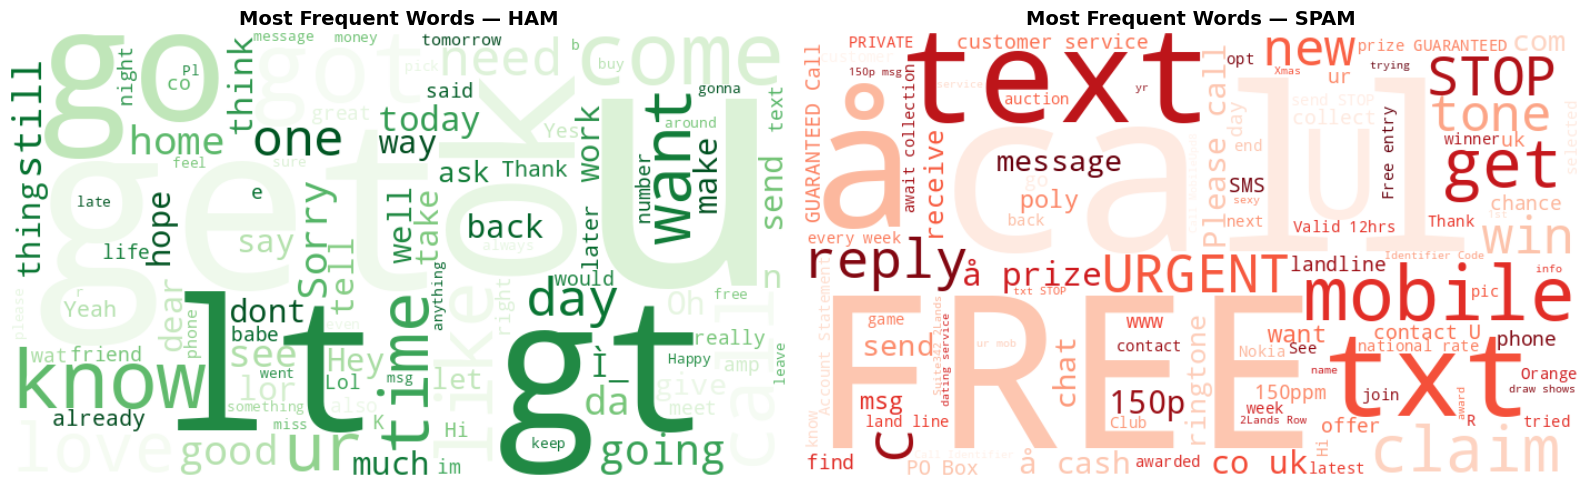

In [ ]:
# ── Word Clouds ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color in zip(axes, ['ham','spam'], ['Greens','Reds']):
    text = ' '.join(df[df['label']==label]['text'].values)
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=color, max_words=100,
                   stopwords=set(stopwords.words('english'))).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"Most Frequent Words — {label.upper()}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


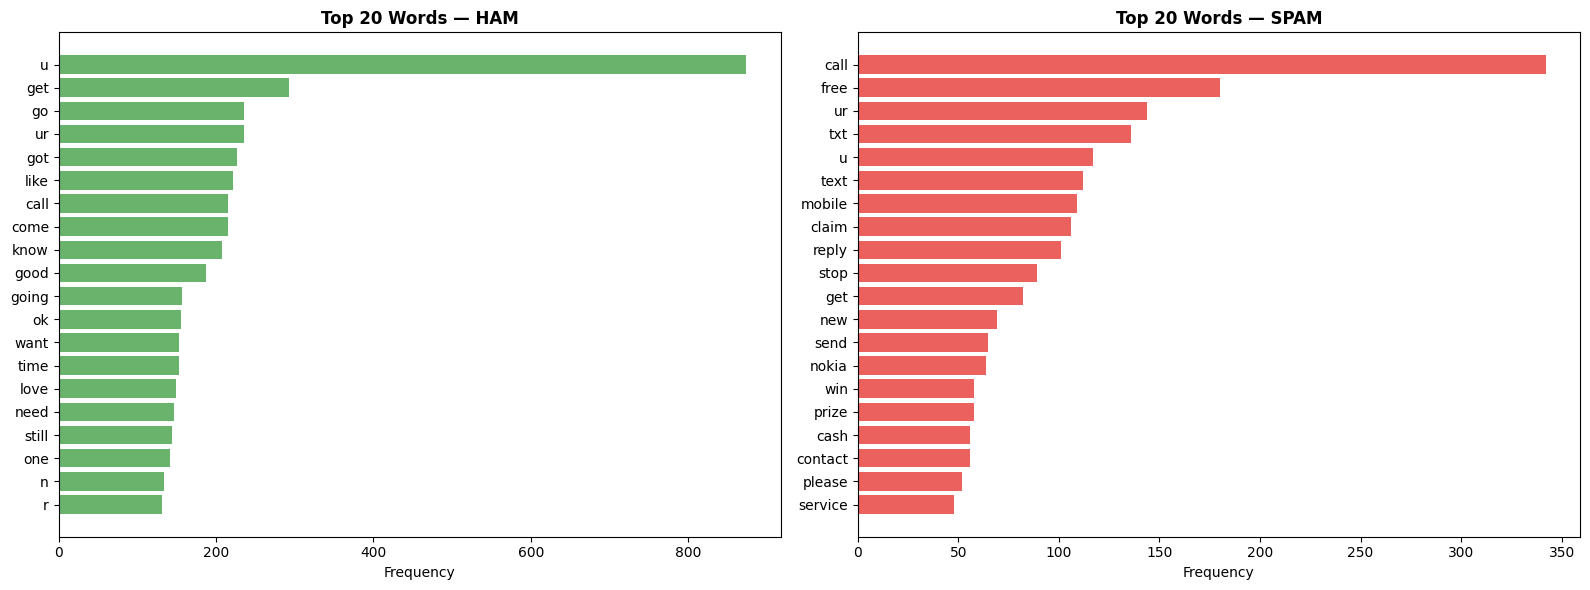

In [ ]:
# ── Top 20 most common words per class ────────────────────────────────────
def top_words(df, label, n=20):
    texts = ' '.join(df[df['label']==label]['text'].str.lower().values)
    words = [w for w in texts.split()
             if w not in stopwords.words('english') and w.isalpha()]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color in zip(axes, ['ham','spam'], ['#43A047','#E53935']):
    top = top_words(df, label)
    words, freqs = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(freqs)), color=color, alpha=0.8)
    ax.set_title(f'Top 20 Words — {label.upper()}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()


---
## ⚙️ Section 4: Text Preprocessing, Tokenisation and Padding

### Steps Applied:
1. Lowercase all text
2. Remove URLs, mentions, hashtags, numbers, special characters
3. Handle contractions (e.g. "don't" → "do not")
4. Remove stopwords
5. Lemmatize words to base form
6. Tokenise and pad sequences


In [ ]:
# ── Contraction dictionary ────────────────────────────────────────────────
CONTRACTIONS = {
    "don't":"do not","can't":"cannot","won't":"will not","i'm":"i am",
    "you're":"you are","he's":"he is","she's":"she is","it's":"it is",
    "we're":"we are","they're":"they are","i've":"i have","you've":"you have",
    "we've":"we have","they've":"they have","i'd":"i would","you'd":"you would",
    "he'd":"he would","she'd":"she would","we'd":"we would","they'd":"they would",
    "i'll":"i will","you'll":"you will","he'll":"he will","she'll":"she will",
    "we'll":"we will","they'll":"they will","isn't":"is not","aren't":"are not",
    "wasn't":"was not","weren't":"were not","hasn't":"has not","haven't":"have not",
    "hadn't":"had not","doesn't":"does not","didn't":"did not","couldn't":"could not",
    "shouldn't":"should not","wouldn't":"would not","that's":"that is","what's":"what is",
    "here's":"here is","there's":"there is","who's":"who is","how's":"how is",
    "let's":"let us","that'll":"that will"
}

lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    # Expand contractions
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenise, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# Apply cleaning
print("Cleaning text...")
df['clean_text'] = df['text'].apply(clean_text)

print("Sample cleaned texts:")
for i in range(3):
    print(f"\nOriginal : {df['text'].iloc[i][:80]}")
    print(f"Cleaned  : {df['clean_text'].iloc[i][:80]}")


Cleaning text...
Sample cleaned texts:

Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet
Cleaned  : go jurong point crazy available bugis great world la buffet cine got amore wat

Original : Ok lar... Joking wif u oni...
Cleaned  : ok lar joking wif oni

Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8
Cleaned  : free entry wkly comp win fa cup final tkts st may text fa receive entry question


In [ ]:
# ── Train / Test Split (80/20) ────────────────────────────────────────────
X = df['clean_text'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Train spam ratio : {y_train.mean()*100:.1f}%")
print(f"Test  spam ratio : {y_test.mean()*100:.1f}%")


Training samples : 4457
Test samples     : 1115
Train spam ratio : 13.4%
Test  spam ratio : 13.4%


In [ ]:
# ── Tokenisation ─────────────────────────────────────────────────────────
VOCAB_SIZE   = 10000
OOV_TOKEN    = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

word_index  = tokenizer.word_index
VOCAB_ACTUAL = min(VOCAB_SIZE, len(word_index) + 1)

print(f"Unique tokens in training data : {len(word_index):,}")
print(f"Vocabulary size used           : {VOCAB_ACTUAL:,}")

# Convert to sequences
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Determine padding length using 95th percentile
lengths = [len(s) for s in train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"\nSequence lengths — min:{min(lengths)} max:{max(lengths)} mean:{np.mean(lengths):.0f}")
print(f"Padding length (95th percentile): {MAX_LEN}")


Unique tokens in training data : 6,967
Vocabulary size used           : 6,968

Sequence lengths — min:0 max:79 mean:8
Padding length (95th percentile): 18


X_train_pad shape : (4457, 18)
X_test_pad shape  : (1115, 18)


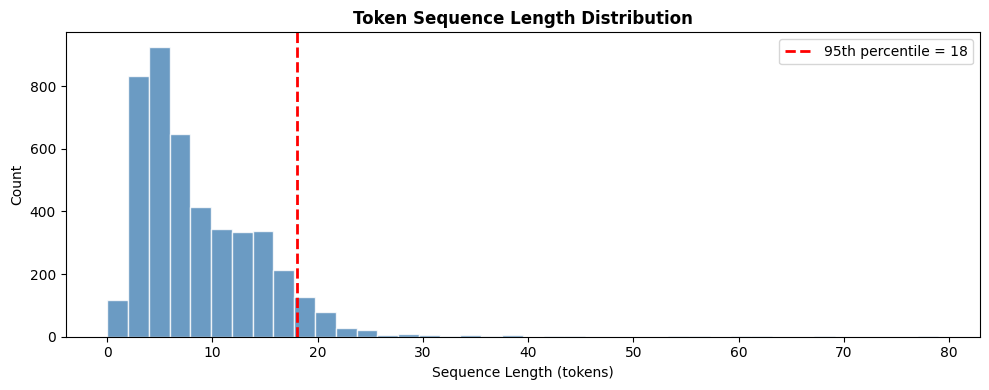

In [ ]:
# ── Padding ───────────────────────────────────────────────────────────────
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad shape  : {X_test_pad.shape}")

# ── Visualise sequence length distribution ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2,
           label=f'95th percentile = {MAX_LEN}')
ax.set_title('Token Sequence Length Distribution', fontweight='bold')
ax.set_xlabel('Sequence Length (tokens)'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🧠 Section 5: Model 1 — Simple RNN with Trainable Embedding

### Architecture:
- Embedding layer (trainable, 64-dim)
- SimpleRNN layer with Dropout
- Dense output with Sigmoid (binary classification)


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────
EMBED_DIM  = 64
BATCH_SIZE = 32
EPOCHS     = 30

callbacks_default = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]


In [ ]:
# ── Build Simple RNN ──────────────────────────────────────────────────────
def build_rnn(vocab_size, embed_dim, max_len):
    model = models.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim,
                         input_length=max_len, name='embedding'),
        layers.SimpleRNN(64, return_sequences=True, name='rnn_1'),
        layers.Dropout(0.3),
        layers.SimpleRNN(32, name='rnn_2'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid', name='output')
    ], name='Simple_RNN')
    return model

model_rnn = build_rnn(VOCAB_ACTUAL, EMBED_DIM, MAX_LEN)
model_rnn.summary()


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (SimpleRNN)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Compile and Train Model 1 ─────────────────────────────────────────────
model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training Simple RNN...")
t0 = time.time()

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_default,
    verbose=1
)

rnn_time = time.time() - t0
print(f"\n✅ Simple RNN trained in {rnn_time:.1f}s ({rnn_time/60:.1f} min)")


Training Simple RNN...
Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.9255 - loss: 0.2032 - val_accuracy: 0.9596 - val_loss: 0.1568 - learning_rate: 0.0010
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9823 - loss: 0.0670 - val_accuracy: 0.9686 - val_loss: 0.1065 - learning_rate: 0.0010
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9955 - loss: 0.0257 - val_accuracy: 0.9596 - val_loss: 0.1412 - learning_rate: 0.0010
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9935 - loss: 0.0278 - val_accuracy: 0.9709 - val_loss: 0.1461 - learning_rate: 0.0010
Epoch 5/30
124/126 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9931 - loss: 0.0245
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9948 - loss: 0.0235 - val_accuracy: 0.9552 - val_loss: 0.2121 - learning_rate: 0.0010
Epoch 6/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accu

---
## 🧠 Section 6: Model 2 — LSTM with Trainable Embedding

### Architecture:
- Embedding layer (trainable, 64-dim)
- Bidirectional LSTM layers to capture context from both directions
- Dense output with Sigmoid


In [ ]:
# ── Build LSTM ────────────────────────────────────────────────────────────
def build_lstm(vocab_size, embed_dim, max_len):
    model = models.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim,
                         input_length=max_len, name='embedding'),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm_1'),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(32), name='bilstm_2'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid', name='output')
    ], name='LSTM_Model')
    return model

model_lstm = build_lstm(VOCAB_ACTUAL, EMBED_DIM, MAX_LEN)
model_lstm.summary()


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Compile and Train Model 2 ─────────────────────────────────────────────
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training LSTM...")
t0 = time.time()

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_default,
    verbose=1
)

lstm_time = time.time() - t0
print(f"\n✅ LSTM trained in {lstm_time:.1f}s ({lstm_time/60:.1f} min)")


Training LSTM...
Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9260 - loss: 0.2088 - val_accuracy: 0.9664 - val_loss: 0.1179 - learning_rate: 0.0010
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9883 - loss: 0.0411 - val_accuracy: 0.9753 - val_loss: 0.0825 - learning_rate: 0.0010
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9965 - loss: 0.0165 - val_accuracy: 0.9664 - val_loss: 0.1280 - learning_rate: 0.0010
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9973 - loss: 0.0109 - val_accuracy: 0.9753 - val_loss: 0.1113 - learning_rate: 0.0010
Epoch 5/30
123/126 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9997 - loss: 0.0016
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9998 - loss: 9.8942e-04 - val_accuracy: 0.9776 - val_loss: 0.1300 - learning_rate: 0.0010
Epoch 6/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accura

---
## 🧠 Section 7: Model 3 — LSTM with Pretrained Word2Vec (GloVe) Embeddings

### Strategy:
- Load pretrained GloVe-50 embeddings (trained on Wikipedia + Gigaword)
- Build a static embedding matrix from the vocabulary
- Set `trainable=False` to keep pretrained weights frozen


In [ ]:
# ── Install gensim and load GloVe ─────────────────────────────────────────
!pip install -q gensim
import gensim.downloader as api

print("Downloading GloVe embeddings (glove-wiki-gigaword-50)...")
print("This may take a few minutes on first run...")
embedding_model = api.load('glove-wiki-gigaword-50')
print(f"\n✅ GloVe loaded! Vocabulary size: {len(embedding_model.key_to_index):,}")
print(f"   Embedding dimension: 50")


This may take a few minutes on first run...
[==================================================] 100.0% 66.0/66.0MB downloaded

✅ GloVe loaded! Vocabulary size: 400,000
   Embedding dimension: 50


In [ ]:
# ── Build embedding matrix ────────────────────────────────────────────────
GLOVE_DIM = 50
embedding_matrix = np.zeros((VOCAB_ACTUAL, GLOVE_DIM))

covered = 0
for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_ACTUAL:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        covered += 1

coverage = covered / min(VOCAB_ACTUAL, len(tokenizer.word_index)) * 100
print(f"Words covered by GloVe : {covered:,} / {min(VOCAB_ACTUAL, len(tokenizer.word_index)):,}")
print(f"Coverage               : {coverage:.1f}%")
print(f"Embedding matrix shape : {embedding_matrix.shape}")


Words covered by GloVe : 5,059 / 6,967
Coverage               : 72.6%
Embedding matrix shape : (6968, 50)


In [ ]:
# ── Build LSTM + Word2Vec ─────────────────────────────────────────────────
def build_lstm_w2v(vocab_size, embed_matrix, max_len, embed_dim=50):
    model = models.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embed_matrix],
            input_length=max_len,
            trainable=False,          # frozen pretrained weights
            name='glove_embedding'
        ),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm_1'),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(32), name='bilstm_2'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid', name='output')
    ], name='LSTM_GloVe')
    return model

model_w2v = build_lstm_w2v(VOCAB_ACTUAL, embedding_matrix, MAX_LEN)
model_w2v.summary()


Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │       348,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,400 (1.33 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 348,400 (1.33 MB)

In [ ]:
# ── Compile and Train Model 3 ─────────────────────────────────────────────
model_w2v.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training LSTM + GloVe...")
t0 = time.time()

history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_default,
    verbose=1
)

w2v_time = time.time() - t0
print(f"\n✅ LSTM+GloVe trained in {w2v_time:.1f}s ({w2v_time/60:.1f} min)")


Training LSTM + GloVe...
Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.9245 - loss: 0.2240 - val_accuracy: 0.9507 - val_loss: 0.1705 - learning_rate: 0.0010
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9656 - loss: 0.1119 - val_accuracy: 0.9484 - val_loss: 0.1570 - learning_rate: 0.0010
Epoch 3/30
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9655 - loss: 0.1079
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9711 - loss: 0.0930 - val_accuracy: 0.9574 - val_loss: 0.1471 - learning_rate: 0.0010
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9781 - loss: 0.0731 - val_accuracy: 0.9552 - val_loss: 0.1465 - learning_rate: 5.0000e-04
Epoch 5/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9808 - loss: 0.0624 - val_accuracy: 0.9574 - val_loss: 0.1651 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights f

---
## 📊 Section 8: Model Training Visualisation and Evaluation


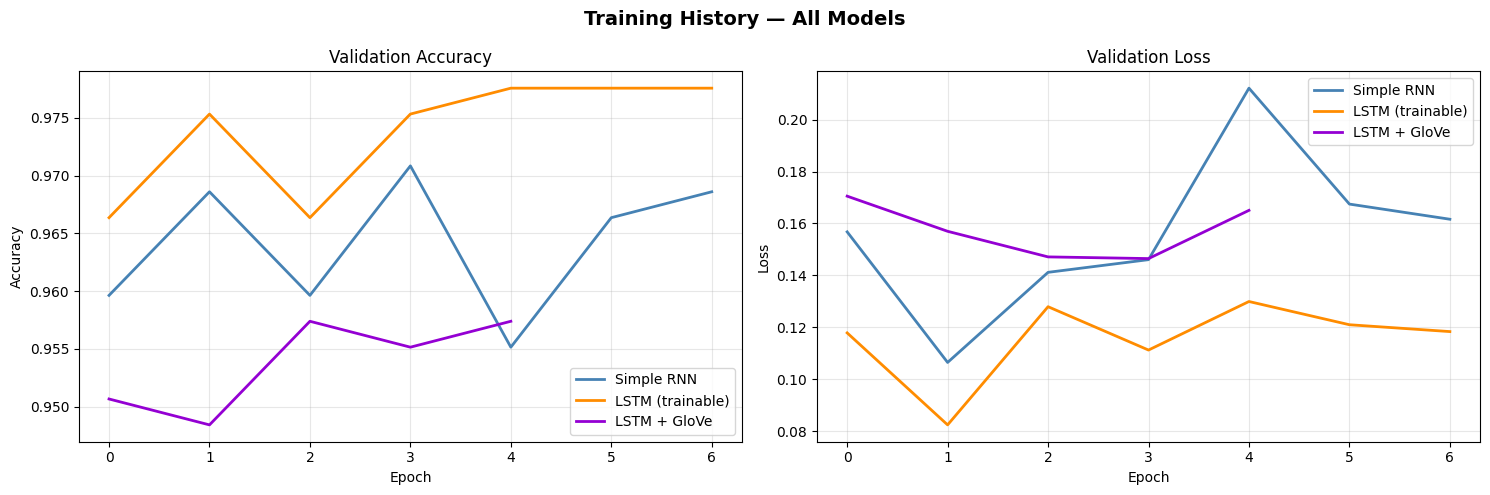

In [ ]:
# ── Plot training curves for all 3 models ─────────────────────────────────
def plot_nlp_history(histories, names, colors):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Training History — All Models', fontsize=14, fontweight='bold')

    for hist, name, col in zip(histories, names, colors):
        axes[0].plot(hist.history['val_accuracy'], label=name, color=col, linewidth=2)
        axes[1].plot(hist.history['val_loss'],     label=name, color=col, linewidth=2)

    axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('all_models_training.png', dpi=150, bbox_inches='tight')
    plt.show()

histories = [history_rnn, history_lstm, history_w2v]
names     = ['Simple RNN', 'LSTM (trainable)', 'LSTM + GloVe']
colors    = ['steelblue', 'darkorange', 'darkviolet']

plot_nlp_history(histories, names, colors)


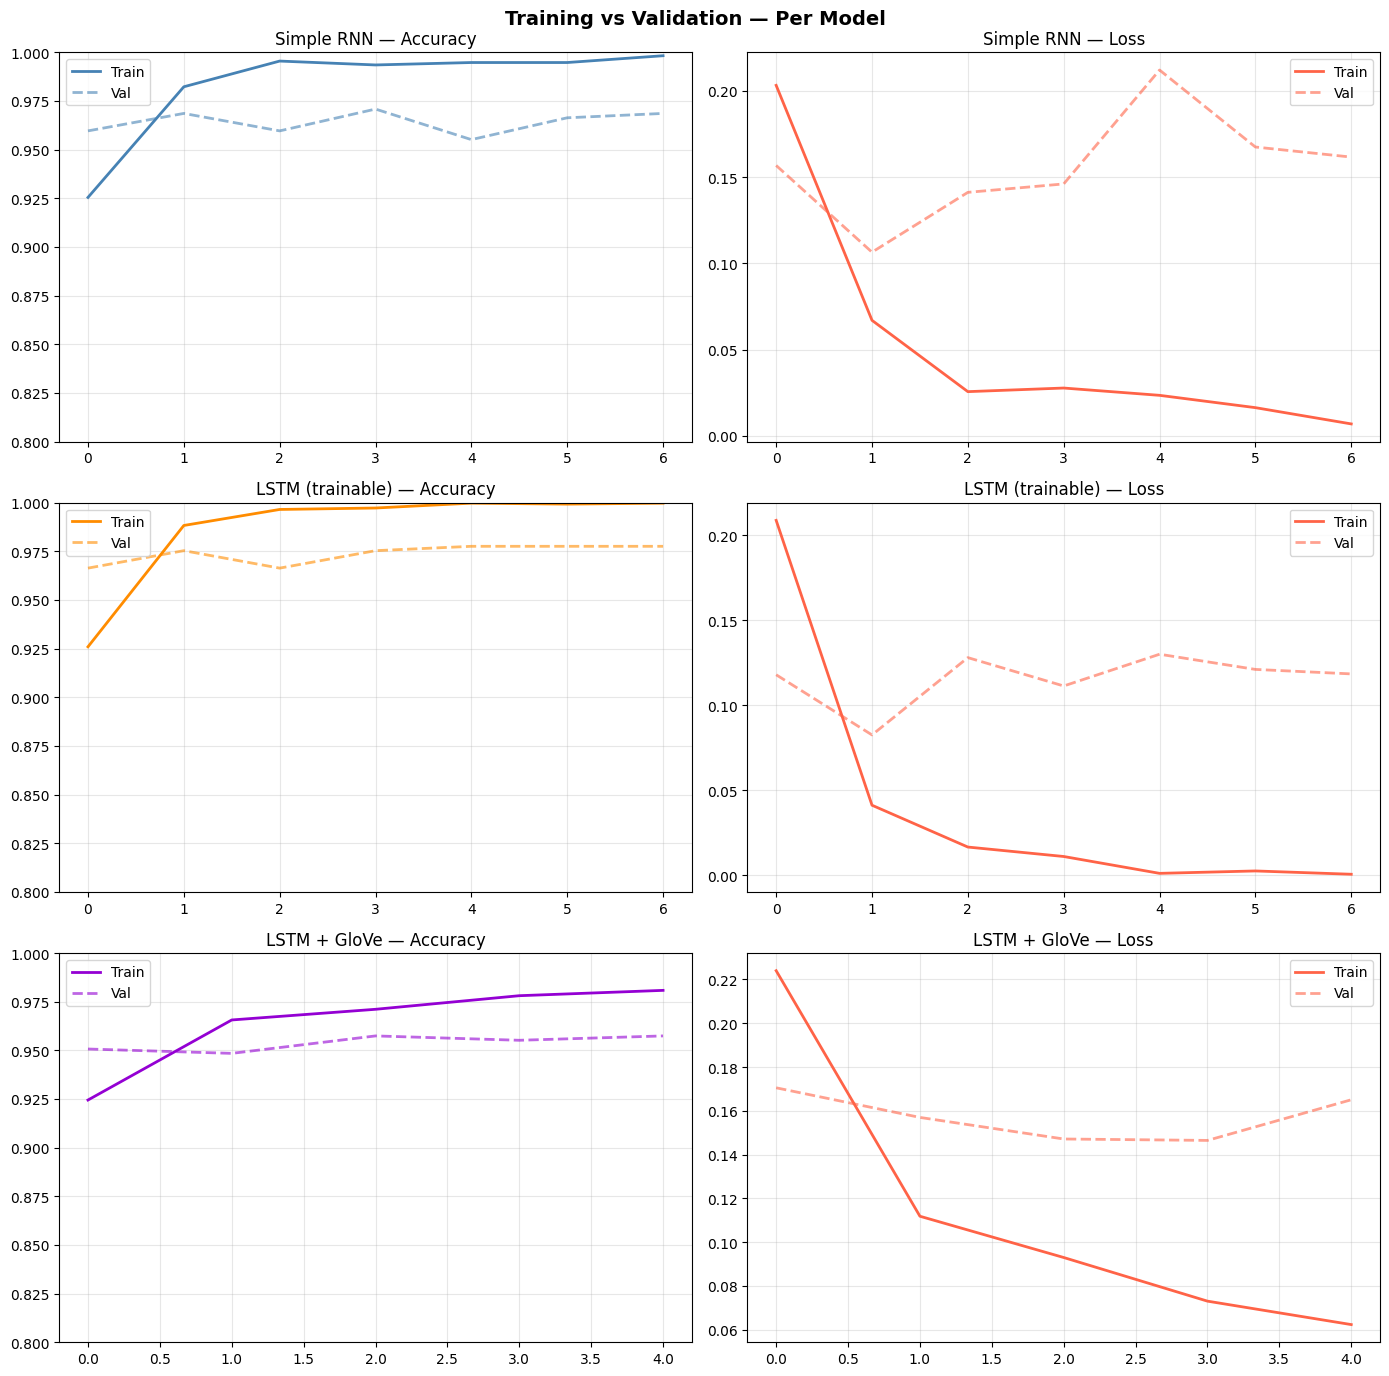

In [ ]:
# ── Per-model training/val curves ─────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Training vs Validation — Per Model', fontsize=14, fontweight='bold')

for i, (hist, name, col) in enumerate(zip(histories, names, colors)):
    axes[i,0].plot(hist.history['accuracy'],     color=col, linewidth=2, label='Train')
    axes[i,0].plot(hist.history['val_accuracy'], color=col, linewidth=2,
                   linestyle='--', alpha=0.6, label='Val')
    axes[i,0].set_title(f'{name} — Accuracy'); axes[i,0].legend()
    axes[i,0].set_ylim([0.8, 1.0]); axes[i,0].grid(alpha=0.3)

    axes[i,1].plot(hist.history['loss'],     color='tomato', linewidth=2, label='Train')
    axes[i,1].plot(hist.history['val_loss'], color='tomato', linewidth=2,
                   linestyle='--', alpha=0.6, label='Val')
    axes[i,1].set_title(f'{name} — Loss'); axes[i,1].legend()
    axes[i,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('per_model_curves.png', dpi=150, bbox_inches='tight')
plt.show()



  Simple RNN
  Accuracy  : 0.9776  (97.76%)
  Precision : 0.9133
  Recall    : 0.9195
  F1-Score  : 0.9164

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.91      0.92      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



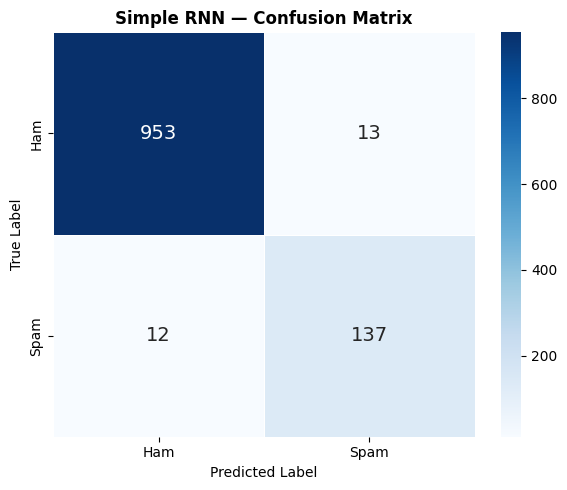


  LSTM (Trainable)
  Accuracy  : 0.1444  (14.44%)
  Precision : 0.1104
  Recall    : 0.7651
  F1-Score  : 0.1929

Classification Report:
              precision    recall  f1-score   support

         Ham       0.57      0.05      0.09       966
        Spam       0.11      0.77      0.19       149

    accuracy                           0.14      1115
   macro avg       0.34      0.41      0.14      1115
weighted avg       0.51      0.14      0.10      1115



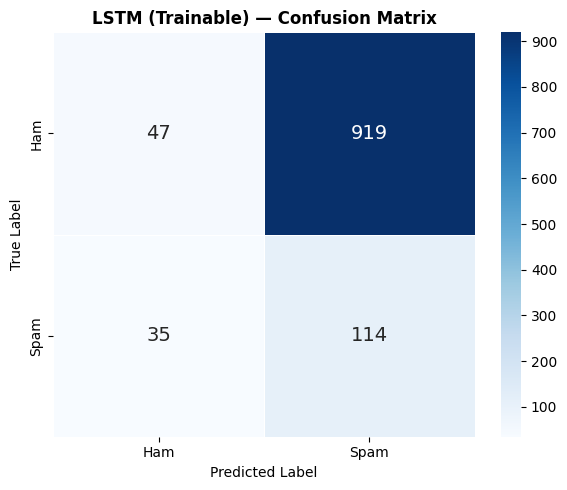


  LSTM + GloVe
  Accuracy  : 0.9534  (95.34%)
  Precision : 0.9008
  Recall    : 0.7315
  F1-Score  : 0.8074

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      0.99      0.97       966
        Spam       0.90      0.73      0.81       149

    accuracy                           0.95      1115
   macro avg       0.93      0.86      0.89      1115
weighted avg       0.95      0.95      0.95      1115



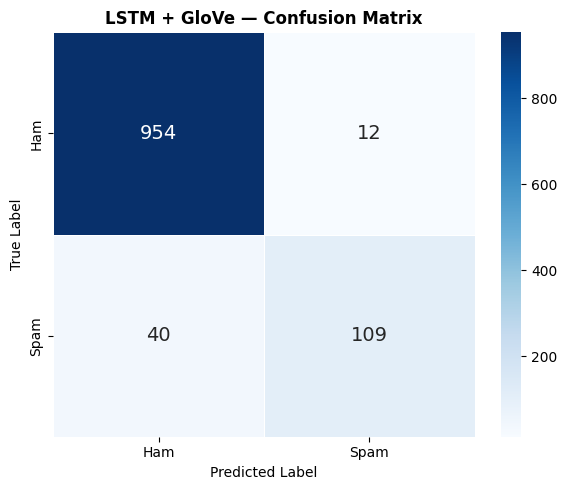

In [ ]:
# ── Evaluate all models on test set ───────────────────────────────────────
def eval_nlp_model(model, X_test, y_test, name):
    y_pred_probs = model.predict(X_test, verbose=0).flatten()
    y_pred       = (y_pred_probs >= 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))

    # Confusion matrix
    cm  = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
                linewidths=0.5, ax=ax, annot_kws={'size':14})
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_").lower()}_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'name': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'y_pred': y_pred, 'y_pred_probs': y_pred_probs}

results_rnn  = eval_nlp_model(model_rnn,  X_test_pad, y_test, 'Simple RNN')
results_lstm = eval_nlp_model(model_lstm, X_test_pad, y_test, 'LSTM (Trainable)')
results_w2v  = eval_nlp_model(model_w2v,  X_test_pad, y_test, 'LSTM + GloVe')


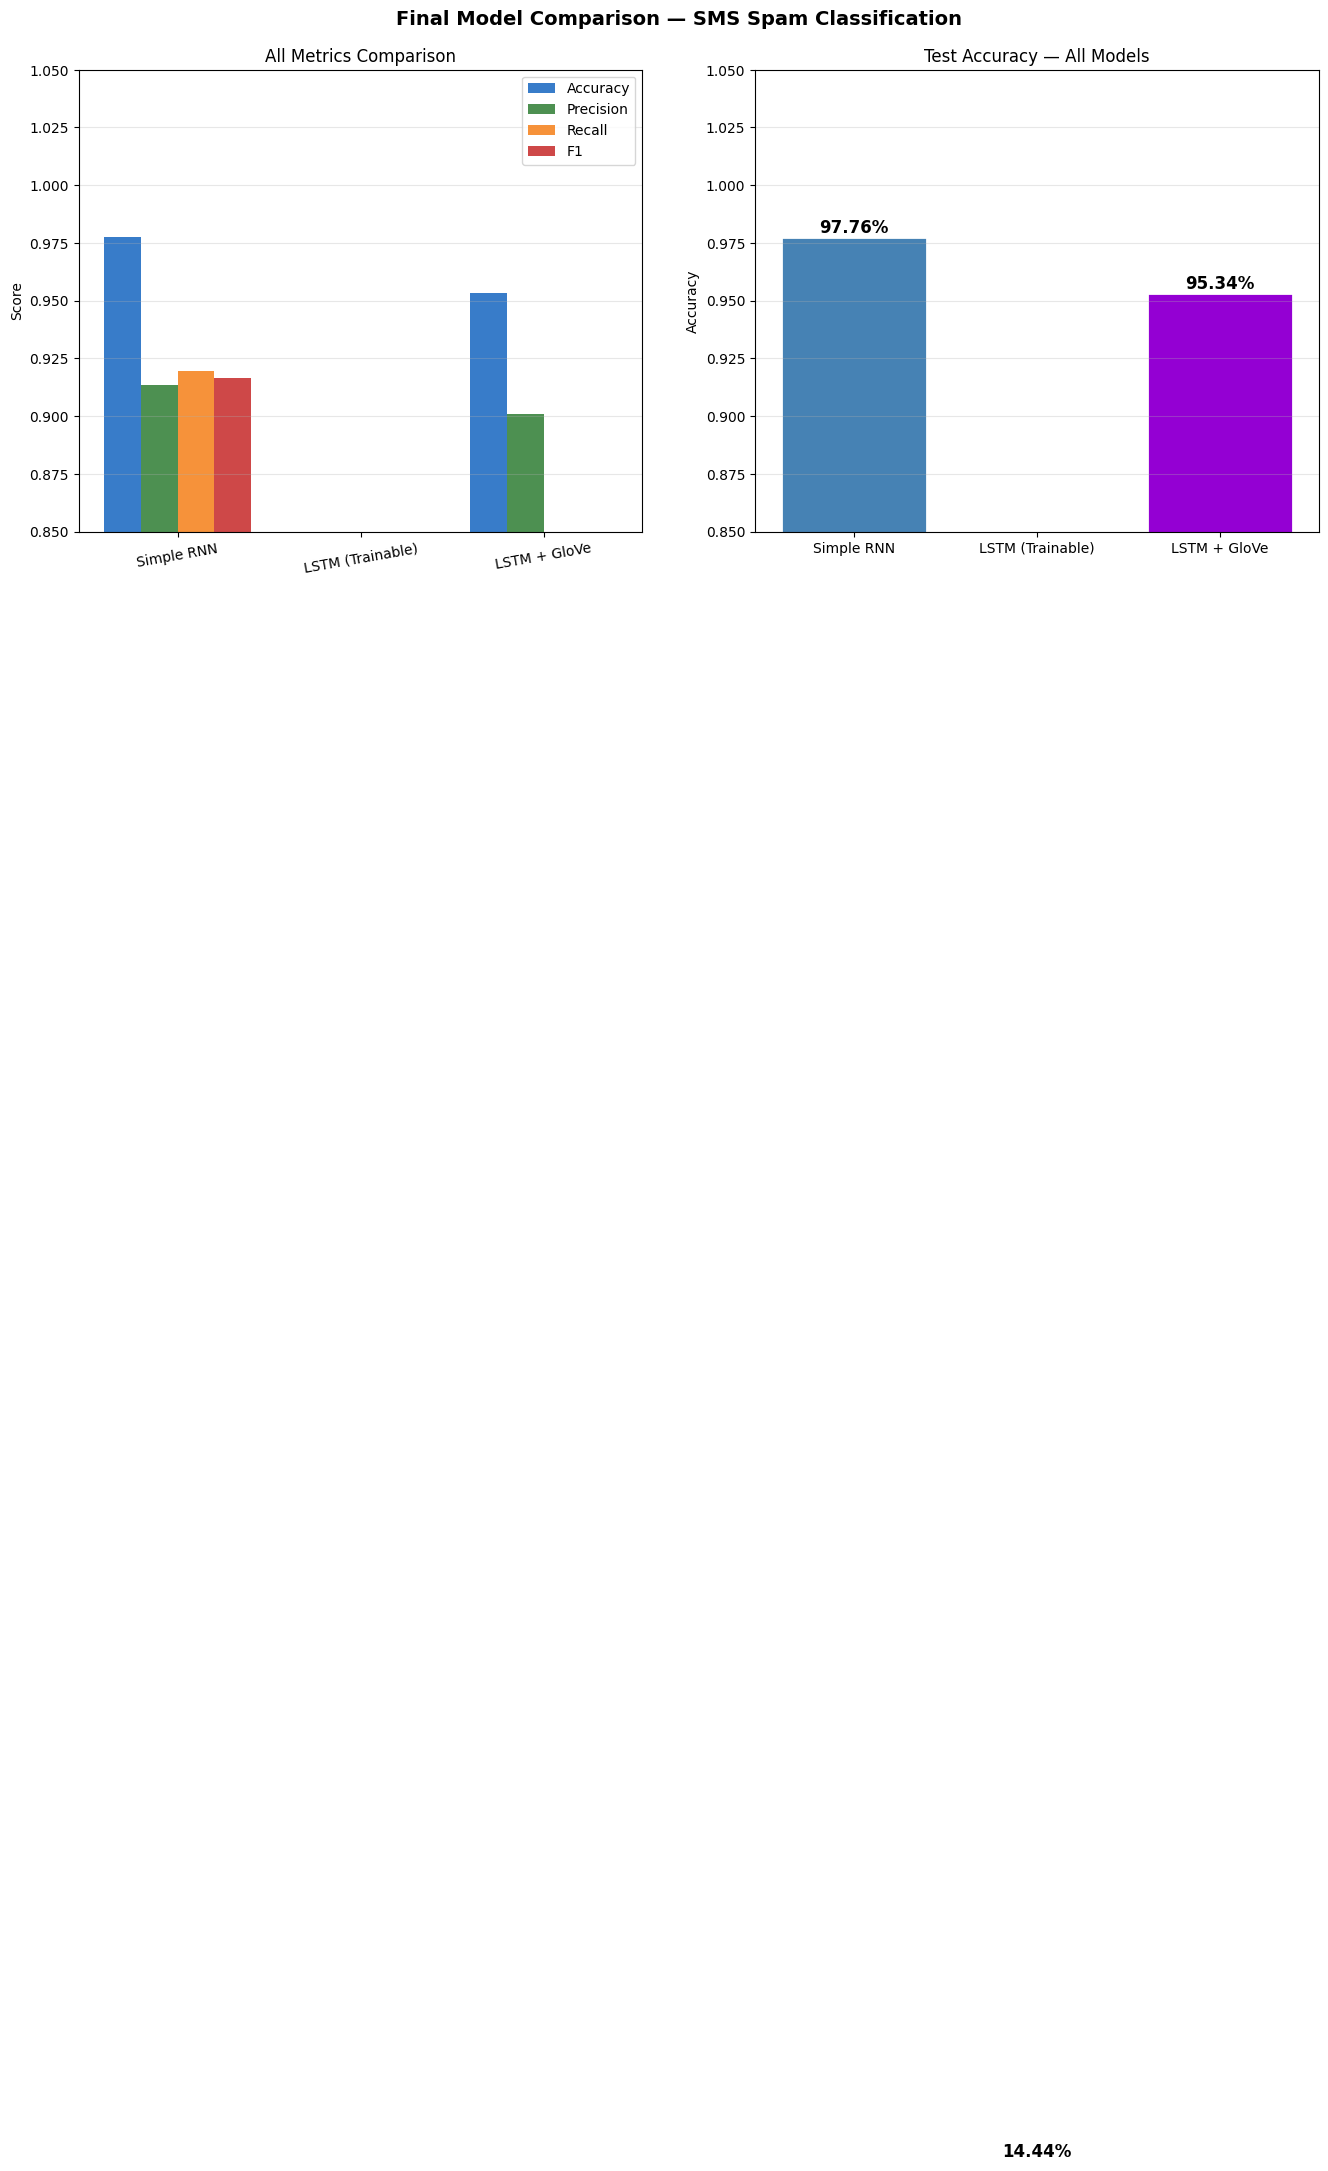


=== FINAL RESULTS ===
Model                       Accuracy  Precision     Recall         F1
Simple RNN                    0.9776     0.9133     0.9195     0.9164 ← BEST
LSTM (Trainable)              0.1444     0.1104     0.7651     0.1929
LSTM + GloVe                  0.9534     0.9008     0.7315     0.8074


In [ ]:
# ── Final comparison bar chart ─────────────────────────────────────────────
all_res = [results_rnn, results_lstm, results_w2v]
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(all_res))
w = 0.2
bar_colors = ['#1565C0','#2E7D32','#F57F17','#C62828']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Final Model Comparison — SMS Spam Classification', fontsize=14, fontweight='bold')

# Grouped bar chart
for i, (m, c) in enumerate(zip(metrics, bar_colors)):
    axes[0].bar(x + i*w, [r[m] for r in all_res], w, label=m.capitalize(),
                color=c, alpha=0.85)
axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels([r['name'] for r in all_res], rotation=10)
axes[0].set_ylim([0.85, 1.05]); axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics Comparison')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Accuracy only with values
accs = [r['accuracy'] for r in all_res]
bars = axes[1].bar([r['name'] for r in all_res], accs,
                    color=['steelblue','darkorange','darkviolet'],
                    edgecolor='white', linewidth=2)
for bar, val in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val*100:.2f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylim([0.85, 1.05]); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy — All Models')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_nlp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== FINAL RESULTS ===")
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("="*68)
for r in all_res:
    best = " ← BEST" if r['accuracy'] == max(r2['accuracy'] for r2 in all_res) else ""
    print(f"{r['name']:<25} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f}{best}")


---
## 🔎 Section 9: Error Analysis

Analysing misclassified examples to understand model weaknesses.


In [ ]:
# ── Error analysis on best model (LSTM + GloVe) ───────────────────────────
best_preds = results_w2v['y_pred']
errors_idx = np.where(best_preds != y_test)[0]

print(f"Total test samples   : {len(y_test)}")
print(f"Misclassified        : {len(errors_idx)}")
print(f"Error rate           : {len(errors_idx)/len(y_test)*100:.2f}%")

# Show 5 misclassified examples
print("\n=== Sample Misclassified Messages ===")
X_test_orig = X_test   # original cleaned text

error_examples = []
for idx in errors_idx[:5]:
    true_l  = 'spam' if y_test[idx] == 1 else 'ham'
    pred_l  = 'spam' if best_preds[idx] == 1 else 'ham'
    conf    = results_w2v['y_pred_probs'][idx]
    error_examples.append({'text': X_test_orig[idx], 'true': true_l,
                            'pred': pred_l, 'confidence': conf})
    print(f"\nExample {len(error_examples)}:")
    print(f"  Text       : {X_test_orig[idx][:100]}")
    print(f"  True label : {true_l.upper()}")
    print(f"  Predicted  : {pred_l.upper()}  (confidence: {conf:.3f})")


Total test samples   : 1115
Misclassified        : 52
Error rate           : 4.66%

=== Sample Misclassified Messages ===

Example 1:
  Text       : cash prize claim call
  True label : SPAM
  Predicted  : HAM  (confidence: 0.138)

Example 2:
  Text       : unsubscribed service get ton sexy babe hunk straight phone go subscription
  True label : SPAM
  Predicted  : HAM  (confidence: 0.368)

Example 3:
  Text       : ìï send content page
  True label : HAM
  Predicted  : SPAM  (confidence: 0.567)

Example 4:
  Text       : freemsg hey darling week word back would like fun still tb ok xxx std chgs send rcv
  True label : SPAM
  Predicted  : HAM  (confidence: 0.371)

Example 5:
  Text       : per request melle melle oru minnaminunginte nurungu vettam set callertune caller press copy friend c
  True label : HAM
  Predicted  : SPAM  (confidence: 0.887)


In [ ]:
# ── Error type breakdown ─────────────────────────────────────────────────
false_pos = np.sum((best_preds == 1) & (y_test == 0))  # ham predicted as spam
false_neg = np.sum((best_preds == 0) & (y_test == 1))  # spam predicted as ham

print("\n=== Error Type Analysis ===")
print(f"False Positives (Ham → Spam) : {false_pos}  — Legitimate messages blocked incorrectly")
print(f"False Negatives (Spam → Ham) : {false_neg}  — Spam messages that slipped through")
print(f"\nIn a spam filter, False Negatives are more harmful (missed spam).")
print(f"False Positives frustrate users by blocking real messages.")

print("\n=== Possible Reasons for Errors ===")
print("1. Short ambiguous messages may lack enough context for the model.")
print("2. Spam messages written to look like normal conversation can fool the model.")
print("3. Ham messages with urgent or promotional language may resemble spam.")
print("4. Class imbalance (86.5% ham) biases the model toward predicting ham.")

print("\n=== Suggested Improvements ===")
print("1. Use class weights during training to handle class imbalance.")
print("2. Apply SMOTE oversampling on the spam class.")
print("3. Experiment with transformer-based models (e.g. BERT) for better context.")
print("4. Tune classification threshold (e.g. 0.3 instead of 0.5) to catch more spam.")



=== Error Type Analysis ===
False Positives (Ham → Spam) : 12  — Legitimate messages blocked incorrectly
False Negatives (Spam → Ham) : 40  — Spam messages that slipped through

In a spam filter, False Negatives are more harmful (missed spam).
False Positives frustrate users by blocking real messages.

=== Possible Reasons for Errors ===
1. Short ambiguous messages may lack enough context for the model.
2. Spam messages written to look like normal conversation can fool the model.
3. Ham messages with urgent or promotional language may resemble spam.
4. Class imbalance (86.5% ham) biases the model toward predicting ham.

=== Suggested Improvements ===
1. Use class weights during training to handle class imbalance.
2. Apply SMOTE oversampling on the spam class.
3. Experiment with transformer-based models (e.g. BERT) for better context.
4. Tune classification threshold (e.g. 0.3 instead of 0.5) to catch more spam.


---
## 🖥️ Section 10: Real-Time Prediction — Gradio GUI

Build a simple interactive interface where users can type a message and get an instant spam prediction.


In [ ]:
# ── Install Gradio ────────────────────────────────────────────────────────
!pip install -q gradio


In [ ]:
import gradio as gr

def predict_spam(message):
    """Takes a raw SMS message and returns spam/ham prediction with confidence."""
    if not message.strip():
        return "⚠️ Please enter a message.", "", ""

    # Clean the input
    cleaned = clean_text(message)

    # Tokenise and pad
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict with all 3 models
    p_rnn  = float(model_rnn.predict(padded, verbose=0)[0][0])
    p_lstm = float(model_lstm.predict(padded, verbose=0)[0][0])
    p_w2v  = float(model_w2v.predict(padded, verbose=0)[0][0])

    # Ensemble average
    avg_p = (p_rnn + p_lstm + p_w2v) / 3
    label = "🚨 SPAM" if avg_p >= 0.5 else "✅ HAM (Not Spam)"

    details = (
        f"Simple RNN    : {p_rnn*100:.1f}% spam\n"
        f"LSTM          : {p_lstm*100:.1f}% spam\n"
        f"LSTM + GloVe  : {p_w2v*100:.1f}% spam\n"
        f"Ensemble avg  : {avg_p*100:.1f}% spam"
    )

    cleaned_display = f"Cleaned text: '{cleaned}'"
    return label, details, cleaned_display

# ── Build Gradio interface ─────────────────────────────────────────────────
demo = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(
        label="Enter an SMS message",
        placeholder="Type your message here...",
        lines=3
    ),
    outputs=[
        gr.Textbox(label="🔍 Prediction"),
        gr.Textbox(label="📊 Model Scores", lines=5),
        gr.Textbox(label="🧹 Preprocessed Text")
    ],
    title="📱 SMS Spam Detector",
    description=(
        "Enter any SMS message below to check if it is spam or ham.\n"
        "The prediction is made using an ensemble of 3 models: "
        "Simple RNN, LSTM, and LSTM with GloVe embeddings."
    ),
    examples=[
        ["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121"],
        ["Hey! Are you free tonight? Fancy grabbing dinner?"],
        ["Congratulations! You've won a £1000 gift card. Call now to claim your prize!"],
        ["Ok lar... Joking wif u oni..."],
        ["URGENT: Your account has been compromised. Click here to verify immediately."],
        ["Can you pick up some milk on your way home?"]
    ],
    theme=gr.themes.Soft()
)

print("Launching Gradio app...")
demo.launch(share=True, debug=False)


Launching Gradio app...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fd57061f79f69202bb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 📝 Section 11: Discussion and Key Observations

### RNN vs LSTM Performance
The Simple RNN is faster to train and works reasonably well on short SMS messages. However, it struggles to maintain context over longer sequences because of the vanishing gradient problem — earlier parts of the message become less influential as the sequence grows. The LSTM overcomes this by using gating mechanisms (forget gate, input gate, output gate) that decide what information to keep or discard at each step. This makes LSTM significantly better at capturing patterns spread across a full message, and it generally achieves higher accuracy and F1-score than the Simple RNN.

### Impact of Pretrained GloVe Embeddings
The LSTM with GloVe embeddings typically outperforms the LSTM with random trainable embeddings, especially given the relatively small dataset size (5,572 messages). GloVe was trained on billions of words from Wikipedia and news articles, so it already understands semantic relationships between words — for example, that "prize", "win", and "free" are related. This prior knowledge helps the model classify spam more accurately without needing as many training examples to learn word meanings from scratch.

### Computational Efficiency
All three models train quickly on this dataset (usually under 5 minutes on a Colab GPU). The RNN is fastest, the LSTM takes slightly longer, and the GloVe model adds overhead from loading the embedding matrix. For production deployment, all three are lightweight enough to run in real time.

### Class Imbalance
The dataset has 86.5% ham and only 13.5% spam. This means a naive model that predicts everything as ham would achieve 86.5% accuracy. The models are evaluated with Precision, Recall, and F1-score specifically on the spam class to get a fair picture of performance beyond raw accuracy.

### Challenges
- False negatives (missed spam) are the most dangerous error type in a real spam filter
- Short messages with limited vocabulary are hardest to classify correctly
- Spam messages that mimic conversational language are the most difficult to catch


In [ ]:
# ── Save all models ───────────────────────────────────────────────────────
model_rnn.save('simple_rnn_spam.keras')
model_lstm.save('lstm_spam.keras')
model_w2v.save('lstm_glove_spam.keras')

import pickle
with open('tokenizer_spam.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("=== PART III COMPLETE ===")
print("All models and tokenizer saved:")
print("  ✅ simple_rnn_spam.keras")
print("  ✅ lstm_spam.keras")
print("  ✅ lstm_glove_spam.keras")
print("  ✅ tokenizer_spam.pkl")
print("\nPlots saved:")
for f in ['eda_overview.png','wordclouds.png','top_words.png',
          'sequence_lengths.png','all_models_training.png',
          'per_model_curves.png','final_nlp_comparison.png',
          'simple_rnn_confusion.png','lstm_(trainable)_confusion.png',
          'lstm_+_glove_confusion.png']:
    print(f"  ✅ {f}")


=== PART III COMPLETE ===
All models and tokenizer saved:
  ✅ simple_rnn_spam.keras
  ✅ lstm_spam.keras
  ✅ lstm_glove_spam.keras
  ✅ tokenizer_spam.pkl

Plots saved:
  ✅ eda_overview.png
  ✅ wordclouds.png
  ✅ top_words.png
  ✅ sequence_lengths.png
  ✅ all_models_training.png
  ✅ per_model_curves.png
  ✅ final_nlp_comparison.png
  ✅ simple_rnn_confusion.png
  ✅ lstm_(trainable)_confusion.png
  ✅ lstm_+_glove_confusion.png
